# HPO SolarSystemLander

Elise HPO (8D) from `hpo/designs/design.md`.

## Set up

### Set up Colab

In [1]:
# cell: colab-setup

!git clone https://github.com/miwehle/rl_lab.git
%cd rl_lab
%pip install -r hpo/requirements.txt

import sys

sys.path.insert(0, "dqn/src")
sys.path.insert(0, "hpo/src")

from hpo.notebook.colab import setup_colab

COLAB = setup_colab()

Mounted at /content/drive


### Set up HPO

In [2]:
# cell: hpo-setup # requires: colab-setup

import torch
from hpo.notebook.colab import prepare_storage

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OBSERVATION_MODE = "10d"
STUDY_SERIES_NAME = f"solar_system_lander_{OBSERVATION_MODE}_elise_accel"
STUDY_SERIES_STORAGE = prepare_storage(COLAB, STUDY_SERIES_NAME)

## Optimize HPs iteratively

### Define baseline

Choose on of the following alternatives.

#### For a new study series

In [ ]:
# cell: baseline-1

from hpo.hyperparams import HP
from hpo.study import Baseline

_BASELINE_PARAMS = {
    HP.LEARNING_RATE: 0.0022727854024196057,
    HP.BATCH_SIZE: 512,
    HP.EPS_END: 0.047716002108220544,
    HP.EPS_DECAY: 43_214,
    HP.GAMMA: 0.99,
    HP.TAU: 0.005,
    HP.LEARNING_STARTS: 2_500,
    HP.OPTIMIZE_EVERY: 2,
    HP.REPLAY_MEMORY_CAPACITY: 400_000,
    HP.NUM_EPISODES: 500,
}

baseline = Baseline(params=_BASELINE_PARAMS)

#### For a new study in a series

In [ ]:
# cell: baseline-2

_STUDY_NAME = ...

import optuna

from hpo.notebook.optuna import db_path
from hpo.study import Baseline

_db_path = db_path(STUDY_SERIES_NAME, google_drive=True)

_study = optuna.load_study(
    study_name=_STUDY_NAME,
    storage=f"sqlite:///{_db_path}",
)

_best_trial = max(
    [trial for trial in _study.trials if trial.value is not None],
    key=lambda trial: trial.value,
)

baseline = Baseline(
    params=_best_trial.params,
    score=_best_trial.value,
)

print(_best_trial.number, _best_trial.value)
baseline.params

#### For continuation after Colab runtime loss

In [ ]:
# cell: baseline-2

import optuna

from hpo.notebook.optuna import db_path
from hpo.study import Baseline

_STUDY_NAME = "s3_10d_better_space"

import optuna

from hpo.study import Baseline

_db_path = db_path(STUDY_SERIES_NAME, google_drive=True)

_study = optuna.load_study(
    study_name=_STUDY_NAME,
    storage=f"sqlite:///{_db_path}",
)

_best_trial = max(
    [trial for trial in _study.trials if trial.value is not None],
    key=lambda trial: trial.value,
)

baseline = Baseline(
    params=_best_trial.params,
    score=_study.user_attrs.get("checkpoint_min_score"),
)

baseline.params

### Create study runner

In [3]:
# cell: objective-config # requires: colab-setup, hpo-setup

from hpo.checkpointing import ObjectiveHookFactory
from hpo.objective import ObjectiveConfig
from hpo.solar_system_lander.environment import EnvFactory, worlds_by_name, World

ENV_FACTORY = EnvFactory(
    OBSERVATION_MODE,
    worlds=worlds_by_name(
        World.MERCURY,
        World.VENUS,
        World.VENUS,
        World.VENUS,
        World.VENUS,
        World.EARTH,
        World.EARTH,
        World.EARTH,
        World.EARTH,
        World.MOON,
        World.MARS,
    ),
)

_EARLY_STOPPING_SCORE = -250.0  # optional; default: -250.0; disable: None
OBJECTIVE_CFG = ObjectiveConfig(
    environment_factory=ENV_FACTORY,
    num_envs=22,
    device=device,
    eval_episodes=10,
    early_stopping_score=_EARLY_STOPPING_SCORE,
    hooks=ObjectiveHookFactory(
        checkpoint_dir=COLAB.local_study_dir / f"{STUDY_SERIES_NAME}_checkpoints",
        best_eval_archive_dir=COLAB.drive_study_dir / "best_checkpoints" / STUDY_SERIES_NAME,
        window=100,
    ),
)

In [ ]:
# cell: study-runner # requires: hpo-setup, baseline, objective-config

from hpo.evaluation.dashboard import Dashboard
from hpo.study import StudyRunner

_TRAINING_SCORE_MIN = -500.0  # optional; default: -500.0; disable: None

runner = StudyRunner(
    database_path=lambda _name: STUDY_SERIES_STORAGE.database_path,
    objective_cfg=OBJECTIVE_CFG,
    baseline=baseline,
    reporter=Dashboard(render_mode="safe", training_score_min=_TRAINING_SCORE_MIN),
    study_attrs=ENV_FACTORY.metadata(),
    robust_candidates=5,
    extra_seeds=(1001, 1002, 1003, 1004),
    sync_fn=STUDY_SERIES_STORAGE.backup,
)

### Run studies

In [ ]:
# cell: run-s3-10d-better-space # requires: study-runner

from hpo.hyperparams import HP

def _suggest_params(trial, _incumbent_params):
    trial.suggest_categorical(HP.NUM_EPISODES, [2000])
    trial.suggest_int(HP.REPLAY_MEMORY_CAPACITY, 30_000, 120_000, log=True)
    trial.suggest_float(HP.EPS_END, 0.025, 0.045)
    trial.suggest_int(HP.EPS_DECAY, 25_000, 80_000, log=True)
    trial.suggest_float(HP.LEARNING_RATE, 0.0005, 0.0012, log=True)
    trial.suggest_categorical(HP.BATCH_SIZE, [512])
    trial.suggest_categorical(HP.GAMMA, [0.99, 0.995])
    trial.suggest_categorical(HP.TAU, [0.002, 0.005])
    trial.suggest_categorical(HP.LEARNING_STARTS, [2_500, 5_000])
    trial.suggest_categorical(HP.OPTIMIZE_EVERY, [2])

runner.run("s3_10d_better_space", _suggest_params, 50)

### Checkpoint Robustness Evaluation

In [ ]:
# cell: restore-253-checkpoint-local # requires: hpo-setup

from pathlib import Path
import shutil

_local = Path("/content/rl_lab/hpo/runs/solar_system_lander_10d_elise_accel_checkpoints/trials/trial_0035_eval_best.pt")
_archived = Path("/content/drive/MyDrive/rl_lab/hpo/best_checkpoints/solar_system_lander_10d_elise_accel/best_eval_checkpoint.pt")

_local.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(_archived, _local)

print("restored:", _local)
print("size:", _local.stat().st_size)

In [ ]:
checkpoint_robustness = evaluate_checkpoint_robustness(
    study=_study,
    objective_cfg=OBJECTIVE_CFG,
    top_n=1,
    eval_episodes=1000,  # 200 is enough: 5 worlds -> 5 * 200 = 1000
    progress_fn=runner.reporter.report_robustness_evaluation,
)

checkpoint_robustness

## Analysis

### Score histogram

In [22]:
# cell: checkpoint-world-distributions # requires: checkpoint-robustness

import pandas as pd
import torch

from hpo.checkpoint_robustness import q_net_from_checkpoint
from hpo.notebook.colab import path

_CHECKPOINT_PATH = "/content/rl_lab/hpo/runs/solar_system_lander_10d_elise_accel_checkpoints/trials/trial_0035_eval_best.pt"
_CHECKPOINT_PATH = path("best_checkpoints/solar_system_lander_10d_elise_accel/best_eval_checkpoint.pt", True)
_EPISODES = 100  # 1000

_make_envs = OBJECTIVE_CFG.environment_factory.evaluation_envs()
_device = OBJECTIVE_CFG.device
_q_net_env = next(iter(_make_envs.values()))

_q_net = q_net_from_checkpoint(
    _CHECKPOINT_PATH,
    make_env=_q_net_env,
    device=_device,
)
_q_net.eval()

_rows = []
for _world, _make_env in _make_envs.items():
    for _episode in range(_EPISODES):
        _env = _make_env()
        try:
            _seed = None if OBJECTIVE_CFG.eval_seed is None else OBJECTIVE_CFG.eval_seed + _episode
            _obs, _ = _env.reset(seed=_seed)
            _return = 0.0

            for _ in range(OBJECTIVE_CFG.eval_max_steps):
                _state = torch.as_tensor(_obs, dtype=torch.float32, device=_device).unsqueeze(0)
                with torch.no_grad():
                    _action = int(_q_net(_state).argmax(dim=1).item())

                _obs, _reward, _terminated, _truncated, _ = _env.step(_action)
                _return += float(_reward)
                if _terminated or _truncated:
                    break
        finally:
            _env.close()

        _rows.append({"world": _world, "episode": _episode, "score": _return})

scores = pd.DataFrame(_rows)

summary = scores.groupby("world")["score"].agg(
    episodes="count",
    mean="mean",
    std="std",
    min="min",
    q05=lambda s: s.quantile(0.05),
    q25=lambda s: s.quantile(0.25),
    median="median",
    q75=lambda s: s.quantile(0.75),
    q95=lambda s: s.quantile(0.95),
    max="max",
)

display(summary.round(2))

,episodes,mean,std,min,q05,q25,median,q75,q95,max
world,,,,,,,,,,
earth,100,187.68,116.22,-87.71,-11.30,68.80,250.13,274.45,306.30,320.66
mars,100,275.03,33.56,138.14,192.95,264.76,282.30,292.78,315.40,318.88
mercury,100,270.48,40.77,120.77,177.43,262.05,280.23,294.04,313.87,321.19
moon,100,250.98,72.40,-204.11,132.33,246.13,272.92,293.82,312.44,336.89
venus,100,186.60,116.21,-205.15,-26.72,132.55,231.27,273.73,303.93,320.37


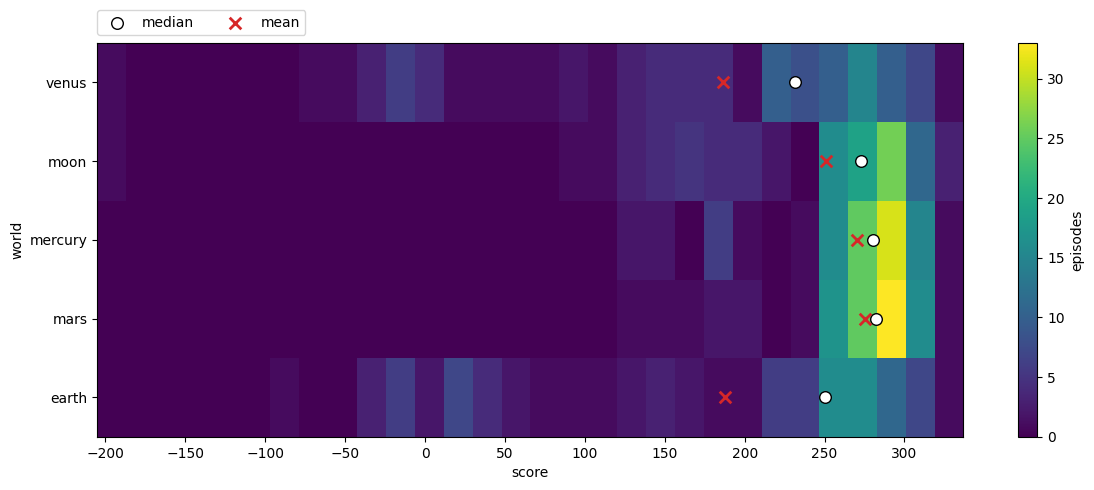

In [34]:
# cell: heatmap-with-mean-median
# requires: checkpoint-world-distributions

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

worlds = ["earth", "mars", "mercury", "moon", "venus"]
bins = np.linspace(scores["score"].min(), scores["score"].max(), 31)
y = np.arange(len(worlds))

histograms = [
    np.histogram(scores.loc[scores["world"] == world, "score"], bins=bins)[0]
    for world in worlds
]
by_world = scores.groupby("world")["score"]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(histograms, aspect="auto", origin="lower", extent=[bins[0], bins[-1], -0.5, len(worlds) - 0.5])

ax.scatter(by_world.median().reindex(worlds), y, marker="o", s=70, facecolors="white", edgecolors="black", label="median")
ax.scatter(by_world.mean().reindex(worlds), y, marker="x", s=70, color="tab:red", linewidths=2, label="mean")

ax.set(xlabel="score", ylabel="world")
ax.set_yticks(y, worlds)
ax.xaxis.set_major_locator(MultipleLocator(50))

fig.colorbar(im, ax=ax, label="episodes")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, borderaxespad=0)

plt.tight_layout()
plt.show()

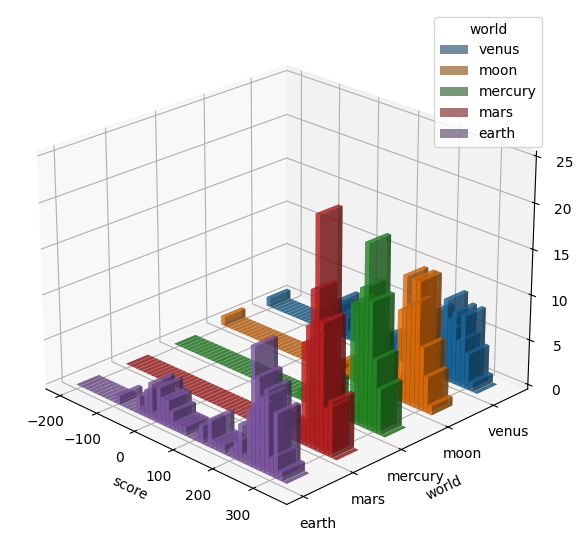

In [25]:
# cell: histogram-3d
# requires: checkpoint-world-distributions

import numpy as np
import matplotlib.pyplot as plt

row_order = ["earth", "mars", "mercury", "moon", "venus"]
draw_order = ["venus", "moon", "mercury", "mars", "earth"]

bins = np.linspace(scores["score"].min(), scores["score"].max(), 51)
centers = (bins[:-1] + bins[1:]) / 2
width = bins[1] - bins[0]

fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(projection="3d", computed_zorder=False)

for world in draw_order:
    y = row_order.index(world)
    counts, _ = np.histogram(scores.loc[scores["world"] == world, "score"], bins=bins)
    ax.bar3d(centers, y, 0, width * 0.9, 0.45, counts, alpha=0.6, zsort="max", label=world)

ax.set(xlabel="score", ylabel="world", zlabel="episodes")
ax.set_yticks(range(len(row_order)), row_order)
ax.view_init(elev=24, azim=-45)
ax.legend(title="world")

plt.show()

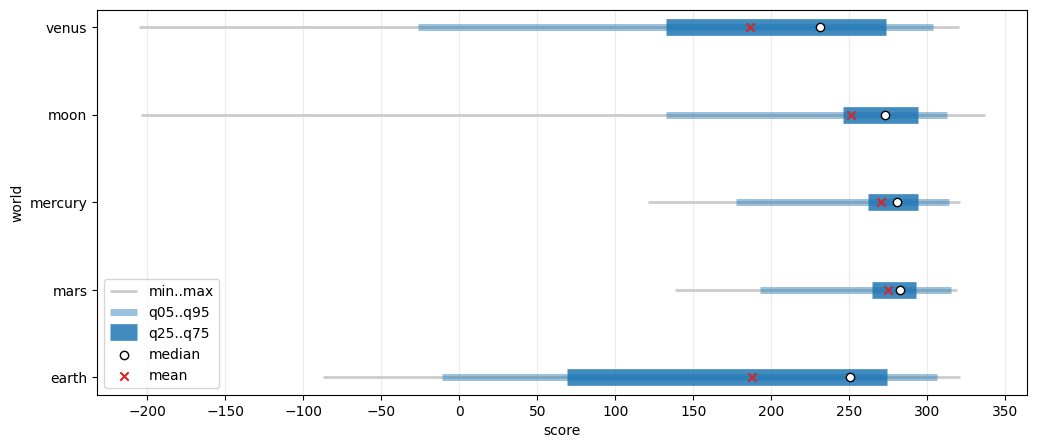

In [ ]:
# cell: quantiles
# requires: checkpoint-world-distributions

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

world_order = ["earth", "mars", "mercury", "moon", "venus"]
data = summary.reindex(world_order)

y = np.arange(len(data))

fig, ax = plt.subplots(figsize=(12, 5))

ax.hlines(y, data["min"], data["max"], color="0.80", linewidth=2, label="min..max")
ax.hlines(y, data["q05"], data["q95"], color="tab:blue", linewidth=5, alpha=0.45, label="q05..q95")
ax.hlines(y, data["q25"], data["q75"], color="tab:blue", linewidth=12, alpha=0.85, label="q25..q75")

ax.scatter(data["median"], y, color="white", edgecolor="black", zorder=3, label="median")
ax.scatter(data["mean"], y, marker="x", color="tab:red", zorder=3, label="mean")

ax.set_xlabel("score")
ax.set_ylabel("world")
ax.set_yticks(y, data.index)
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower left")

plt.show()